# How to use the FIM-SDE Model

This tutorial demonstrates how to use our Foundation Inference Model (FIM) to estimate drift and diffusion functions from stochastic differential equation (SDE) data. This page provides a comprehensive introduction to using our trained SDE model with real data examples.

## Introduction

Stochastic Differential Equations are fundamental mathematical models used to describe systems that evolve over time under the influence of both deterministic forces (drift) and random noise (diffusion). These equations take the form:

```{math}
dx = f(x)dt + G(x)dW(t)
```

where:
- $f(x)$ is the **drift function** representing deterministic evolution
- $G(x)dW(t)$ is the **diffusion term** representing stochastic perturbations
- $W(t)$ is a Wiener process (Brownian motion)

Our model learns to estimate both $f$ and $G$ directly from observed trajectory data in a zero-shot manner, without requiring prior knowledge of the underlying system dynamics.

Let"s start by loading the necessary libraries and the pre-trained model.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
np.set_printoptions(linewidth=100)
from transformers.utils import logging
logging.disable_progress_bar()
from datasets.utils.logging import disable_progress_bar 
disable_progress_bar()

In [2]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import load_dataset
from IPython.display import display

from fim.models.sde import FIMSDE
from fim.utils.sde.solvers import *

from sde_tutorial_helper import prepare_sde_data, plot_sde_results

# Load the pre-trained SDE model
model = FIMSDE.from_pretrained("FIM4Science/fim-sde")
model.eval()

print(f"Model supports up to {model.config.max_dimension}D systems")

Model supports up to 3D systems


:::{note}
For GPU acceleration, you can move both the model and data tensors to your GPU device using `model.to(device)` and `tensor.to(device)` respectively.
:::

## Double Well Potential

Let's start with a classic example in stochastic dynamics - the double well potential. This system exhibits bistable behavior where particles can transition between two stable states due to noise.

In [3]:
# Load the double well dataset
double_well_data = load_dataset("FIM4Science/sde-tutorial-double_well", download_mode="force_redownload")
data_sample = double_well_data["train"][0]  # Get first sample

print("Dataset structure:")
for key, value in data_sample.items():
    if isinstance(value, list) and len(value) > 0 and isinstance(value[0], list):
        shape = f"({len(value)}, {len(value[0])}, ...)"
    else:
        shape = f"({len(value)})"
    print(f"  {key}: {shape}")

Dataset structure:
  observations: (1, 5000, ...)
  locations: (1024, 1, ...)
  initial_states: (5, 1, ...)


In [4]:
# Prepare double well data
dw_input = prepare_sde_data(data_sample, num_paths=3, dt=0.002)

print("Prepared data shapes:")
print(f"  Trajectories: {dw_input['obs_values'].shape}")
print(f"  Times: {dw_input['obs_times'].shape}")
print(f"  Locations: {dw_input['locations'].shape}")

Prepared data shapes:
  Trajectories: torch.Size([1, 1, 5000, 1])
  Times: torch.Size([1, 1, 5000, 1])
  Locations: torch.Size([1, 50, 1])


In [5]:
# Run the model to estimate drift and diffusion
with torch.no_grad():
    dw_estimated_concepts = model(dw_input, training=False)

print(f"Drift shape: {dw_estimated_concepts.drift.shape}")
print(f"Diffusion shape: {dw_estimated_concepts.diffusion.shape}")
print(f"Concepts normalized: {dw_estimated_concepts.normalized}")

Drift shape: torch.Size([1, 50, 3])
Diffusion shape: torch.Size([1, 50, 3])
Concepts normalized: False


## Sampling Paths
The FIM-SDE model can also sample trajectories from the estimated process behind the observed data. Let's try this and see if they behave as we would expect,
e.g. jumping between the two wells and not escaping them.

In [6]:
# Create initial states from the first timestep of observed trajectories
# Shape should be [B, I, D] where B=batch, I=initial_states, D=dimensions
initial_states = (dw_input["obs_values"][:, 0, 0:1, :]).expand(1, 5, 1)  # [1, 5, 1] - first timestep, all dimensions

# Create time grid from observed times
# Shape should be [B, P, T, 1] where P=paths, T=timesteps
time_grid = dw_input["obs_times"]  # [1, 1, 5000, 1] Can be changed to  w_input["locations"] or other coarser grids to speed up sampling
# Expand to match number of paths we want to sample
time_grid = time_grid.expand(1, 5, -1, -1)  # [1, 5, 5000, 1]

# Create mask (all True since we want to sample at all time points)
# Shape should be [B, P, T, 1]
mask = torch.ones_like(time_grid, dtype=torch.bool)  # [1, 5, 5000, 1]

print(f"Initial states shape: {initial_states.shape}")
print(f"Time grid shape: {time_grid.shape}")
print(f"Mask shape {mask.shape}")

Initial states shape: torch.Size([1, 5, 1])
Time grid shape: torch.Size([1, 5, 5000, 1])
Mask shape torch.Size([1, 5, 5000, 1])


In [7]:
# Sample paths using the masked grid function
with torch.no_grad():
    dw_sampled_paths, dw_sampled_paths_grid = fimsde_sample_paths_on_masked_grid(
        model=model,
        data=dw_input,
        grid=time_grid,
        mask=mask,
        initial_states=initial_states,
        solver_granularity=1,
        silent=True
    )

print(f"Sampled paths shape: {dw_sampled_paths.shape}")
print(f"Grid of sampled paths shape: {dw_sampled_paths_grid.shape}")

Sampled paths shape: torch.Size([1, 5, 5000, 1])
Grid of sampled paths shape: torch.Size([1, 5, 5000, 1])


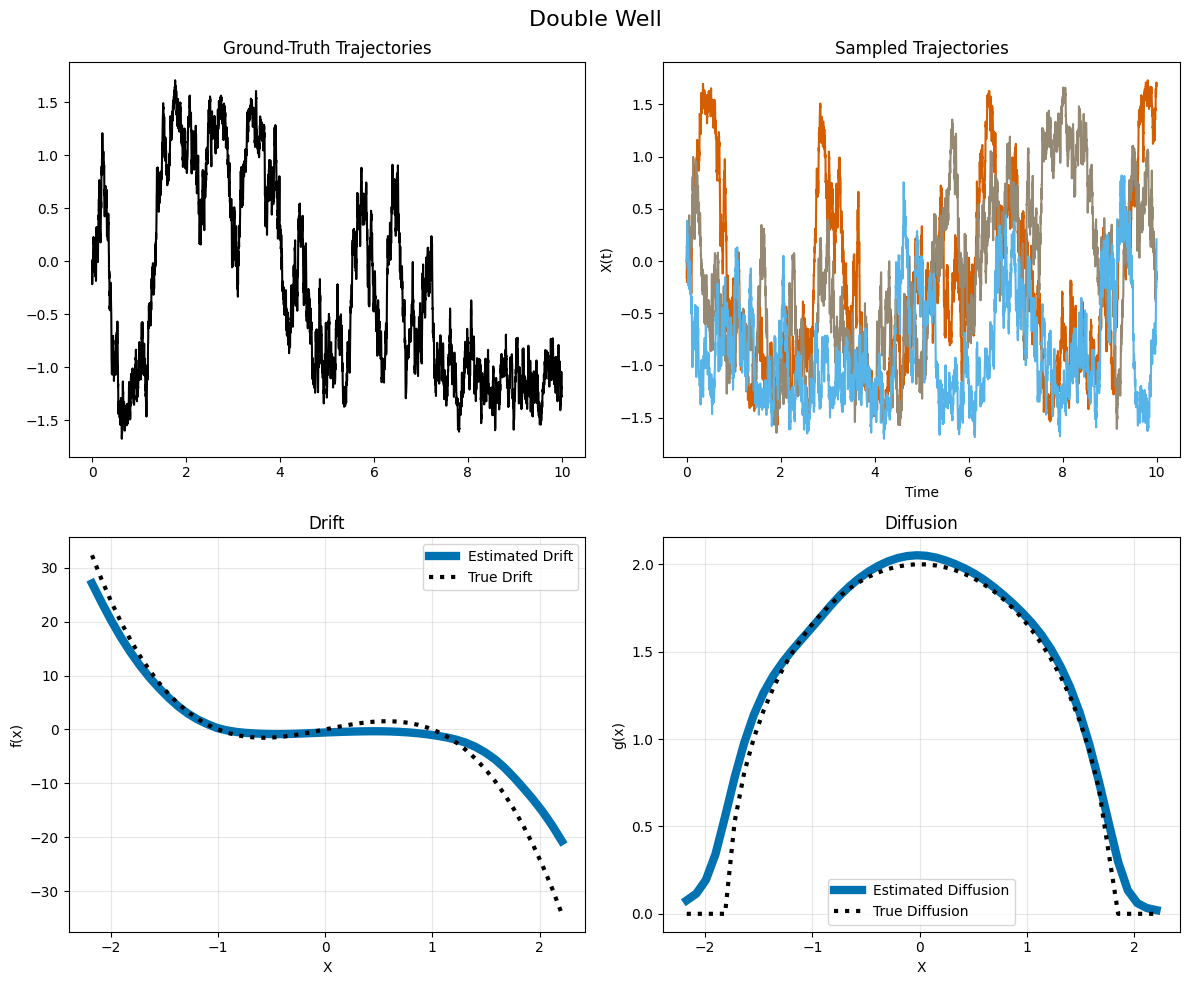

In [8]:
# Create visualization for Double Well
fig = plot_sde_results(dw_input, dw_estimated_concepts, dw_sampled_paths, dw_sampled_paths_grid, "Double Well")
display(fig)
plt.close(fig)

## Duffing Oscillator

In [9]:
duffing_data = load_dataset("FIM4Science/sde-tutorial-duffing", download_mode="force_redownload")
duffing_sample = duffing_data["train"][0]

In [10]:
# Run the model to estimate drift and diffusion
duffing_input = prepare_sde_data(duffing_sample, num_paths=3, dt=0.002)
with torch.no_grad():
    duffing_estimated_concepts = model(duffing_input, training=False)

We can again sample some paths:

In [11]:
# Sample paths using the masked grid function
initial_states = (duffing_input["obs_values"][:, 0, 0:1, :]).expand(1, 5, 2) # [1, 5, 2]
time_grid = duffing_input["obs_times"].broadcast_to(1, 5, 5000, 1) # [1, 5, 5000, 1]
mask = torch.ones_like(time_grid, dtype=torch.bool)  # [1, 5, 5000, 1]

with torch.no_grad():
    duffing_sampled_paths, duffing_sampled_paths_grid = fimsde_sample_paths_on_masked_grid(
        model=model, 
        data=duffing_input, 
        grid=time_grid, 
        mask=mask, 
        initial_states=initial_states, 
        solver_granularity=1, 
        silent=True
    )

print(f"Sampled paths shape: {duffing_sampled_paths.shape}")
print(f"Grid of sampled paths shape: {duffing_sampled_paths_grid.shape}")

Sampled paths shape: torch.Size([1, 5, 5000, 2])
Grid of sampled paths shape: torch.Size([1, 5, 5000, 1])


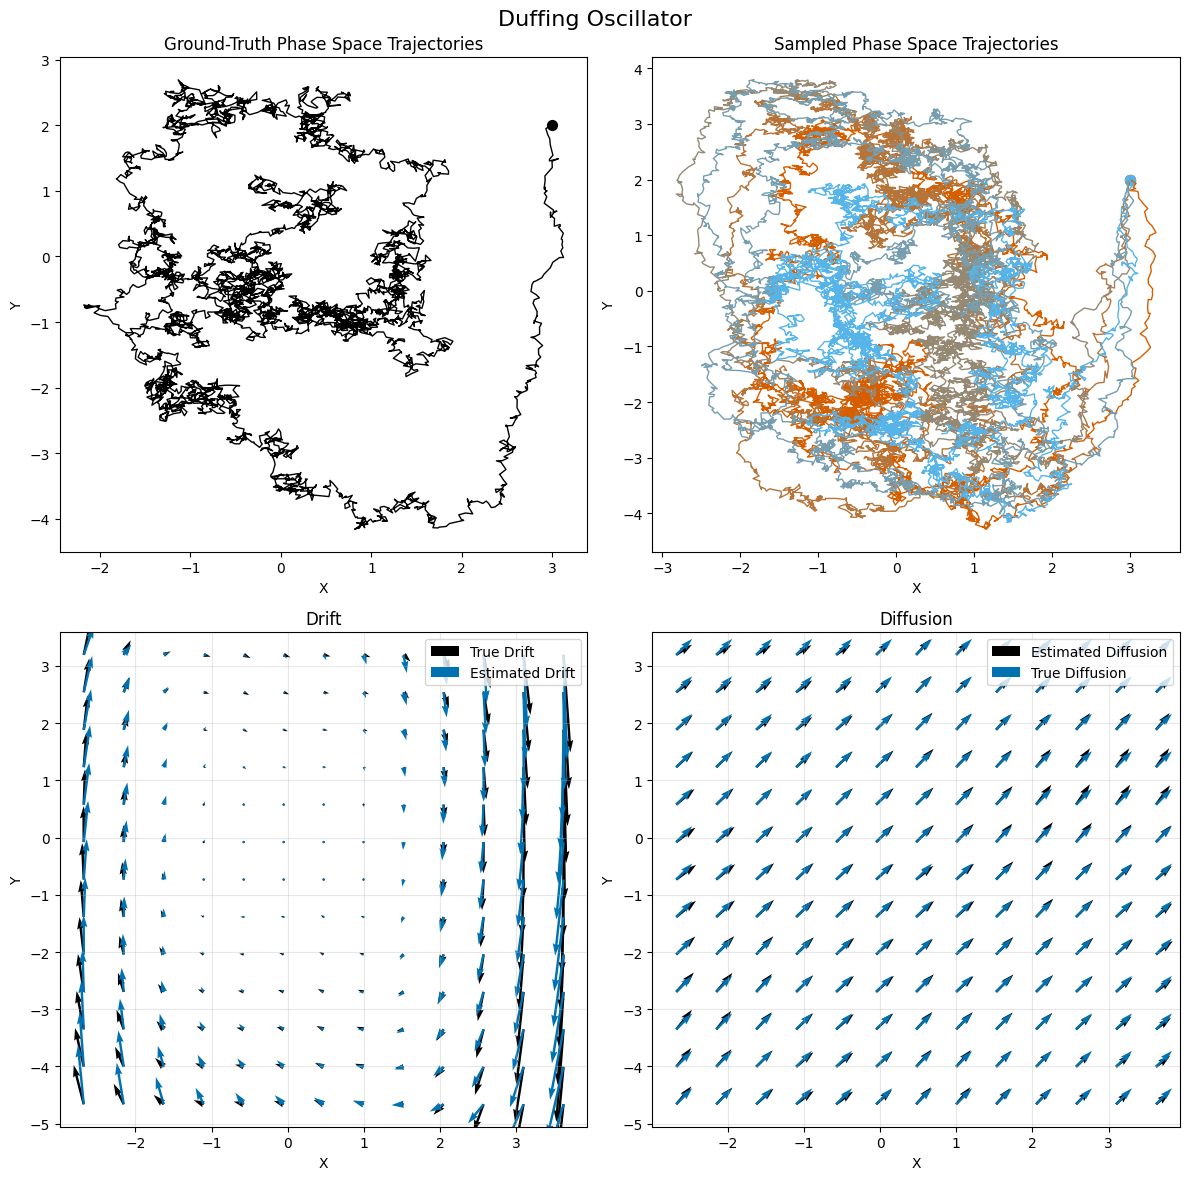

In [12]:
# Create visualization for Duffing oscillator
fig = plot_sde_results(duffing_input, duffing_estimated_concepts, duffing_sampled_paths, duffing_sampled_paths_grid, "Duffing Oscillator")
display(fig)
plt.close(fig)